## В данном ноутбуке проведем анализ основной метрики A/B теста — коэффициента конверсии.

Коэффициент конверсии позволяет определить долю пользователей, совершивших целевое действие в каждой экспериментальной группе.

Мы будем сравнивать:

- контрольную группу A (белый фон сайта)
- тестовую группу B (чёрный фон сайта)

Импортируем библиотеки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Настраиваем стиль и размер будущих графиков

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

Загружаем очищенные данные

In [3]:
df = pd.read_csv('../processed_files/ab_testing_processed.csv')

Рассчитаем коэффициент конверсии по группам

In [4]:
conversion_rate = df.groupby('Group')['Conversion_binary'].mean()
conversion_rate

Group
A    0.053990
B    0.140669
Name: Conversion_binary, dtype: float64

Посчитаем коэффициент конверсии в процентах

In [5]:
conversion_rate_percent = conversion_rate * 100
conversion_rate_percent

Group
A     5.398968
B    14.066909
Name: Conversion_binary, dtype: float64

Определим разницу коэффициента конверсии между тестовой и контрольной группой.
Затем определим относительное изменение конверсии тестовой группы по сравнению с контрольной(uplift).

In [6]:
absolute_difference = conversion_rate['B'] - conversion_rate['A']
print(f'Абсолютная разница: {absolute_difference:.4f}')

uplift = ((conversion_rate['B'] - conversion_rate['A']) / conversion_rate['A']) * 100
print(f'Относительный прирост конверсии: {uplift:.2f}%')

Абсолютная разница: 0.0867
Относительный прирост конверсии: 160.55%


Для более наглядного анализа рассмотрим распределение положительных и отрицательных конверсий внутри каждой группы.

In [7]:
conversion_table = pd.crosstab(df['Group'], df['Conversion'])
conversion_table

Conversion,No,Yes
Group,,
A,2383,136
B,2132,349


Визуализируем коэффициент конверсии

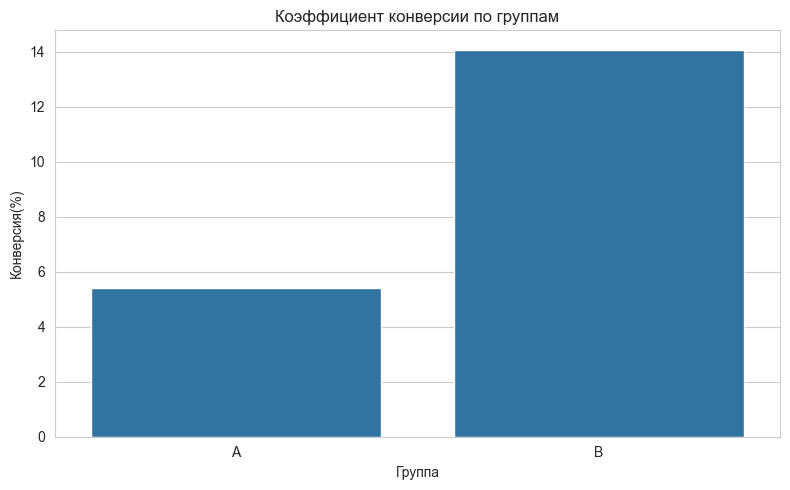

In [8]:
sns.barplot(x = conversion_rate_percent.index, y = conversion_rate_percent.values)
plt.title('Коэффициент конверсии по группам')
plt.ylabel('Конверсия(%)')
plt.xlabel('Группа')
plt.tight_layout()
plt.show()

В тестовой группе B уровень конверсии выше, чем в контрольной группе A.
В A коэффициент конверсии составляет около 5%, для группы B значение примерно 14%.
Полученный результат указывает на возможное положительное влияние экспериментального изменения на вероятность совершения целевого действия пользователем.
Чтобы убедиться в окончательной значимости различий, нужно провести статистический тест.

Нарисуем stacked bar chart по конверсиям

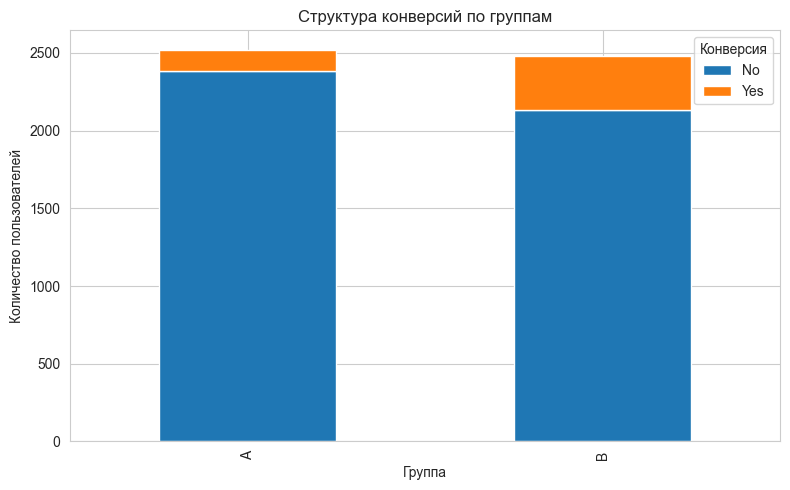

In [9]:
conversion_table.plot(kind = 'bar', stacked = True)
plt.title('Структура конверсий по группам')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.legend(title = 'Конверсия')
plt.tight_layout()
plt.show()